# Time Series Analysis of Financial Markets

## 1. Research Objectives

We now investigate the time series properties of financial market data, exploring whether daily returns are stationary, serial dependence using autocorrelation functions, and evaluate the suitability of time series models such as ARIMA. The aim of this notebook is to determine whether market data is predictive and, if not, to identify any limitations to the models we explore. 

## 2. Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## 3. Load Historical Data

We again want to start with the daily log return:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where:

- $P_t$ = closing price on day $t$
- $P_{t-1}$ = close price on the previous day

In [10]:
spy = yf.download("SPY", start="2015-01-01", end="2026-01-01", auto_adjust=True)

spy["Log_Return"] = np.log(spy["Close"] / spy["Close"].shift(1))

spy = spy.dropna()

spy.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Log_Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2015-01-05,166.623322,168.812251,166.317701,168.647051,169632600,-0.018225
2015-01-06,165.053894,167.449326,164.260916,166.928934,209151400,-0.009464
2015-01-07,167.110718,167.449386,165.929525,166.375567,125346700,0.012385
2015-01-08,170.076050,170.290821,168.498375,168.514886,147217800,0.017589
2015-01-09,168.713150,170.505597,168.101896,170.489073,158567300,-0.008046


## 4. Visualising the Time Series

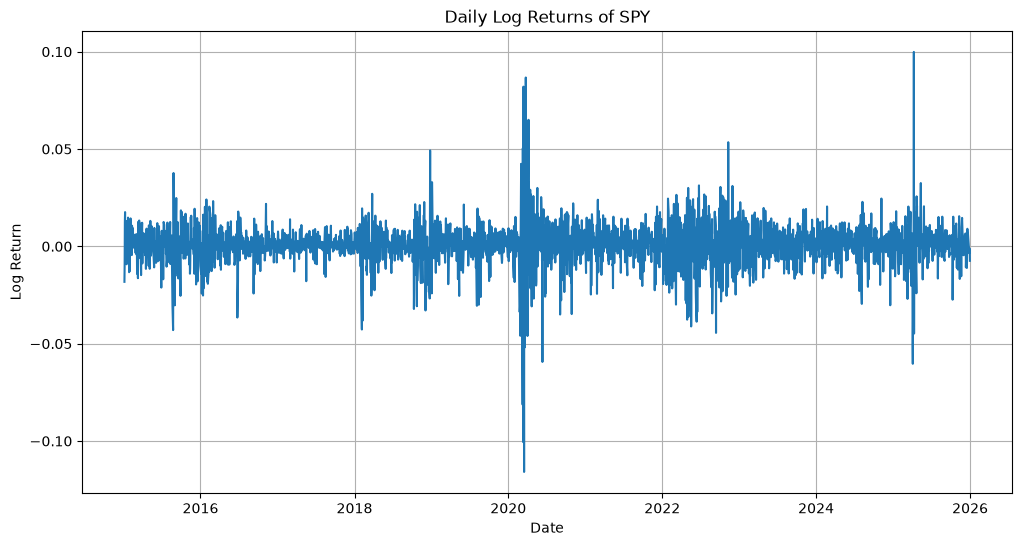

In [11]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["Log_Return"])

plt.title("Daily Log Returns of SPY")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.grid(True)

plt.show()

Initially, this plot shows that daily log returns fluctuate around zero, with a relatively constant average, but there are some periods with much larger volatility.

## 5. Stationary Time Series

### 5.1 Statistical Properties

Commonly, time series assume stationarity which we can describe with three main statistical properties: 

- Constant mean:

$$
E(X_t) = \mu
$$

- Constant variance:

$$
Var(X_t) = \sigma ^2
$$

- Covariance depends only on the time difference, not absolute time:

$$
Cov(X_t,X_{t+k})
$$

This is often true for daily market returns, hence we can attempt to model this using a stationary time series model.

### 5.2 Augmented Dickey-Fuller Test

We begin this test with our hypotheses:

Null Hypothesis:

$H_0$ : The series has a unit root (not stationary)

Alternative Hypothesis:

$H_1$ : The series is stationary


In [12]:
adf_result = adfuller(spy["Log_Return"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
ADF Statistic: -17.038319068301302
p-value: 8.230789471952073e-30


This is quite clearly evidence in favour of the null hypothesis as our p-value $8.230789471952073e-30$ is much smaller than a significance level of $0.05$, highlighting that the SPY daily log return series is indeed stationary. 

## 6. Rolling Mean and Variance

### 6.1 Rolling Mean

The rolling mean calculates the average return over the previous $n$ observations:

$$
\mu_t = \frac{1}{n} \sum^t_{i=t-n+1} r_i
$$

where:

- $\mu_t$ = rolling mean time at time $t$
- $r_i$ = daily log return
- $n$ = rolling window size (again picking $n=30$)

In [13]:
spy["Rolling_Mean"] = spy["Log_Return"].rolling(window=30).mean()

spy["Rolling_Mean"].iloc[30:35]

Date
2015-02-18    0.001362
2015-02-19    0.001653
2015-02-20    0.001440
2015-02-23    0.000849
2015-02-24    0.001211
Name: Rolling_Mean, dtype: float64

### 6.2 Rolling Variance

We also need to recall the rolling variance:

$$
\sigma_t^2 = \frac{1}{n-1} \sum^t_{i=t-n+1} (r_i - \mu_t)^2
$$

where:

- $\sigma^2_t$ = rolling variance
- $\mu_t$ = rolling mean return
- $n$ = rolling window size ($n=30$)

In [14]:
spy["Rolling_Variance"] = spy["Log_Return"].rolling(window=30).var()

spy["Rolling_Variance"].iloc[30:35]

Date
2015-02-18    0.000087
2015-02-19    0.000083
2015-02-20    0.000079
2015-02-23    0.000070
2015-02-24    0.000067
Name: Rolling_Variance, dtype: float64

### 6.3 Visualisations

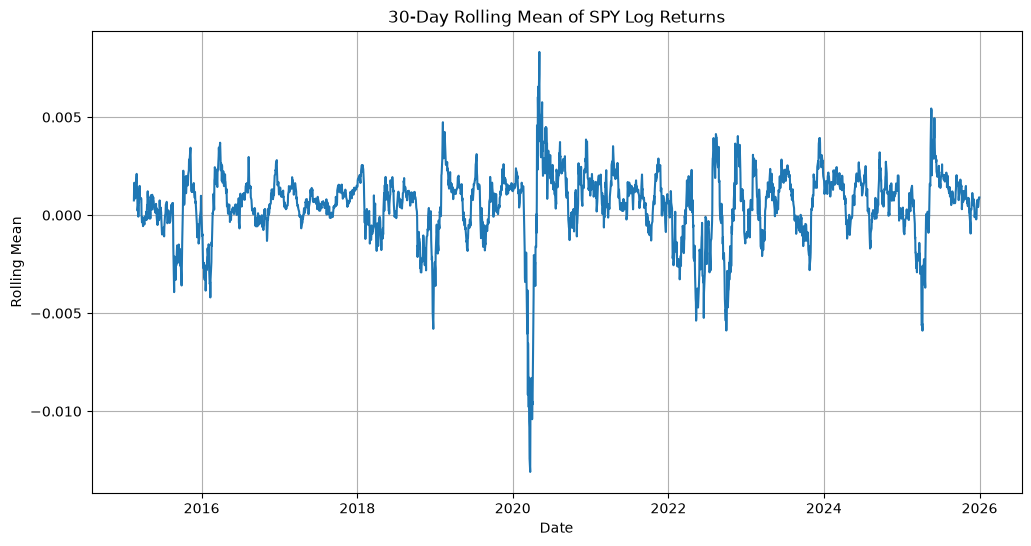

In [15]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["Rolling_Mean"])

plt.title("30-Day Rolling Mean of SPY Log Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Mean")

plt.grid(True)

plt.show()

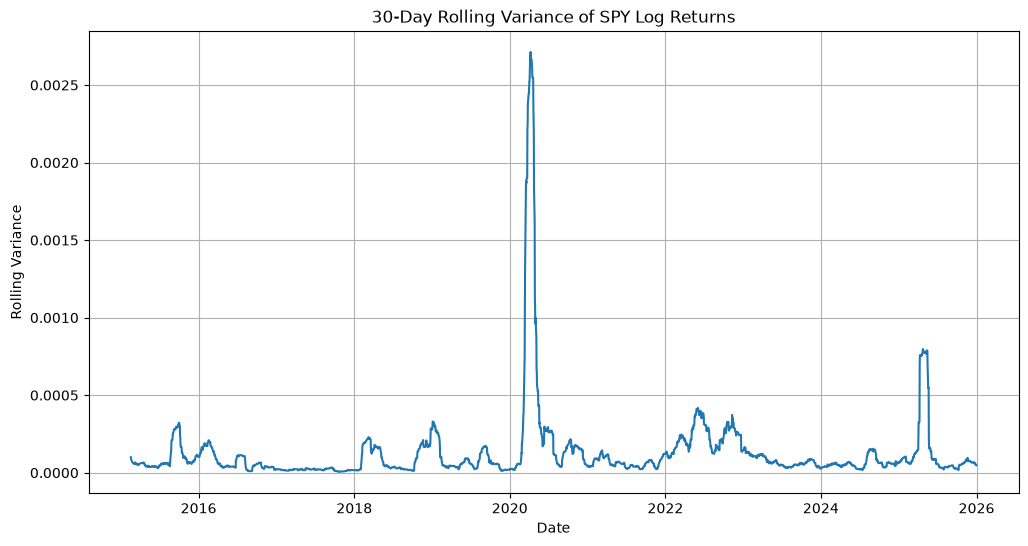

In [17]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["Rolling_Variance"])

plt.title("30-Day Rolling Variance of SPY Log Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Variance")

plt.grid(True)

plt.show()

## 7. Autocorrelation Analysis

### 7.1 Autocorrelation Function (ACF)

The autocorrelation at lag $k$ measures the correlation between a time series and itself shifted by $k$ periods, given by:

$$ \rho_k = \frac{\sum^T_{t=k+1} (r_t -\bar{r})(r_{t-k} - \bar{r})}{\sum^T_{t=1} (r_t - \bar{r})^2} $$

where:

- $\rho_k$ = autocorrelation at lag $k$
- $r_t$ = return at time $k$
- $r_{t-k}$ = return $k$ periods earlier
- $\bar{r}$ = mean return

### 7.2 Plotting the ACF

<Figure size 1200x600 with 0 Axes>

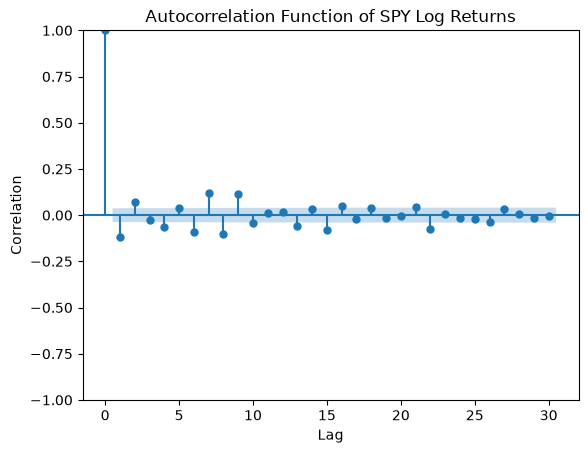

In [20]:
plt.figure(figsize=(12,6))

plot_acf(spy["Log_Return"], lags=30)

plt.title("Autocorrelation Function of SPY Log Returns")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.show()

Looking at this data we see a value of $1.00$ for lag $1$ and the rest of the lags appear to follow a trend, and that trend is a very small correlation value. This indicates that daily SPY returns are approximately unpredictable, and the same can be said for the wider equity marekts.

## 8. Partial Autocorrelation Analysis (PACF)